In [1]:
from pybm.examples.predator_prey import  generate_synthetic_data
import torch

# Generate model and data from /home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py
model, components, times = generate_synthetic_data()
model.engine = "torch"
print(str(model))
# send to torch 
for var_name, var in model.vars.items():
    if var.data is not None:
        var.data.to_torch()
# change times to a torch tensor
t_eval = torch.tensor(times)
# reshape into (1, n_times)
#t_eval = torch.reshape(t_eval, (1, -1))

# print initial values of the variables
print("Initial values of the variables:")
for var_name, var in model.vars.items():
    print(f"{var_name}: {var.initial}")  

# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5 #0.5
model.consts["growth_rate_predator"].initial_value = -0.1 #-0.1
model.consts["predation_rate"].initial_value = 0.05 #0.02
model.consts["conversion_efficiency"].initial_value = 0.05 #0.1



# print initial values of the constants
print("\nInitial values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {const.initial_value}")


Model(Entities: [],
 Vars: ['n_prey', 'n_predator', 'temperature'],
 Consts: ['growth_rate_prey', 'growth_rate_predator', 'predation_rate', 'conversion_efficiency'])
Initial values of the variables:
n_prey: 40.000492061342996
n_predator: 8.016754323781468
temperature: None

Initial values of the constants:
growth_rate_prey: 0.5
growth_rate_predator: -0.1
predation_rate: 0.05
conversion_efficiency: 0.05


In [2]:
# estimate
from pybm.estimate.multishooting_torch import estimate_torch

results = estimate_torch(model, t_eval, method="constraints",
                         n_subintervals=10,
                         maxiter=1500,
                         gtol=0.0001,
                         verbose=2)  # verbose=2 for more detailed output
const_values_torch = results.consts

/home/urhp/Documents/PyBM/src/pybm/utils.py:11: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  inds = torch.searchsorted(xp, x)


| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   1   |   0   | +9.7745e+06 | 1.00e+00 | 2.53e+07 | 1.20e+05 |
|   2   |   3   |   1   | +9.7745e+06 | 4.15e-01 | 2.53e+07 | 1.20e+05 |
|   3   |   4   |   4   | +6.9981e+05 | 4.15e-01 | 6.65e+06 | 9.05e+03 |
|   4   |   5   |   8   | +1.5851e+05 | 4.15e-01 | 3.13e+06 | 3.43e+03 |
|   5   |   6   |  12   | +1.5851e+05 | 4.15e-02 | 3.13e+06 | 3.43e+03 |
|   6   |   7   |  16   | +6.9711e+04 | 1.53e-01 | 8.38e+05 | 1.71e+03 |
|   7   |   8   |  20   | +6.9711e+04 | 1.53e-02 | 8.38e+05 | 1.71e+03 |
|   8   |   9   |  24   | +6.9711e+04 | 5.27e-03 | 8.38e+05 | 1.71e+03 |
|   9   |  10   |  27   | +6.9711e+04 | 1.21e-03 | 8.38e+05 | 1.71e+03 |
|  10   |  11   |  29   | +6.9711e+04 | 4.81e-04 | 8.38e+05 | 1.71e+03 |
|  11   |  12   |  31   | +6.3044e+04 | 3.37e-03 | 3.44e+06 | 1.46e+03 |
|  12   |  13   |  32   | +6.3044e+04 | 3.37e-04 | 

In [3]:
true_const_values = {
    "growth_rate_prey": 0.5,
    "growth_rate_predator": -0.1,
    "predation_rate": 0.02,
    "conversion_efficiency": 0.1
}

# update model constants with estimated values
for const_name, const in model.consts.items():
    const.initial_value = const_values_torch[const.index_in_ctx].item()

print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.51, true value: 0.5
growth_rate_predator: -0.14, true value: -0.1
predation_rate: 0.02, true value: 0.02
conversion_efficiency: 0.09, true value: 0.1


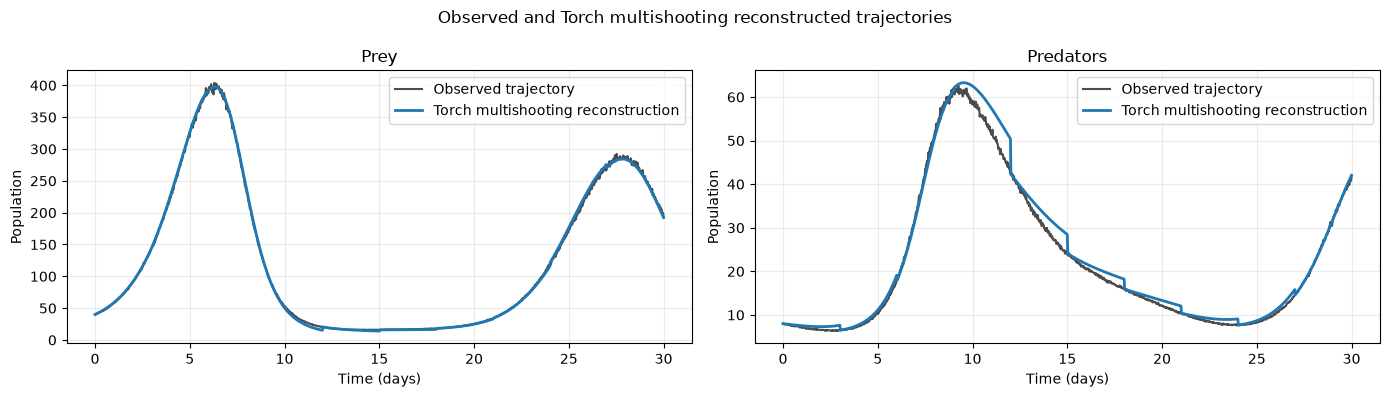

In [5]:
import importlib
import matplotlib.pyplot as plt
import pybm.estimate.multishooting_torch as multishooting_torch_module

multishooting_torch_module = importlib.reload(multishooting_torch_module)
simulate_multishooting_torch = multishooting_torch_module.simulate_multishooting

# Reconstruct the fitted multishooting trajectory from the full parameter vector.
fitted_solution = simulate_multishooting_torch(
    model,
    t_eval,
    params=results.x,
    n_subintervals=10,
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="Torch multishooting reconstruction",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and Torch multishooting reconstructed trajectories")
fig.tight_layout()
plt.show()